# 01 전처리

- 목표: 이상치·결측치·클래스 불균형 전략 비교 후 최적 파이프라인 구성
- 데이터: BRFSS Diabetes Health Indicators, 253,680행, 21개 피처
- 타겟: `Diabetes_binary`, 0/1 이진 분류, 클래스 불균형 약 86:14
- 결정: 이상치·결측치·불균형 처리 방식은 비교 실험 후 결정한다.
- 우선순위: 비교 실험 기반 Recall 최대화 전략 선택
- 저장: 최종 결과를 `outputs/models/train_test_split.pkl`, `outputs/models/preprocessing_pipeline.pkl`에 저장

## 섹션 1 — 데이터 로드

In [1]:

from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from scipy import stats
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

sys.path.append(str(Path('..').resolve()))
from src.preprocessing import ZScoreClipper, detect_outliers_iqr, detect_outliers_zscore, load_data

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font='Malgun Gothic')

DATA_PATH = Path('../data/diabetes_indicators.csv')
FIGURE_DIR = Path('../outputs/figures')
MODEL_DIR = Path('../outputs/models')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = load_data(DATA_PATH)
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
continuous_features = ['BMI', 'MentHlth', 'PhysHlth']

print(f'데이터 형태: {df.shape}')
print(f'클래스 비율:\n{y.value_counts(normalize=True).round(4)}')
print(f'전체 결측치 수: {df.isnull().sum().sum()}')

데이터 형태: (253680, 22)
클래스 비율:
Diabetes_binary
0.0    0.8607
1.0    0.1393
Name: proportion, dtype: float64
전체 결측치 수: 0


## 섹션 2 — 이상치 탐지 비교: IQR vs Z-score

IQR 이상치 수: 9847 (3.88%)
Z-score 이상치 수: 2963 (1.17%)
IQR 이상치 범위: 13.50 ~ 41.50
Z-score 이상치 범위: 8.56 ~ 48.21


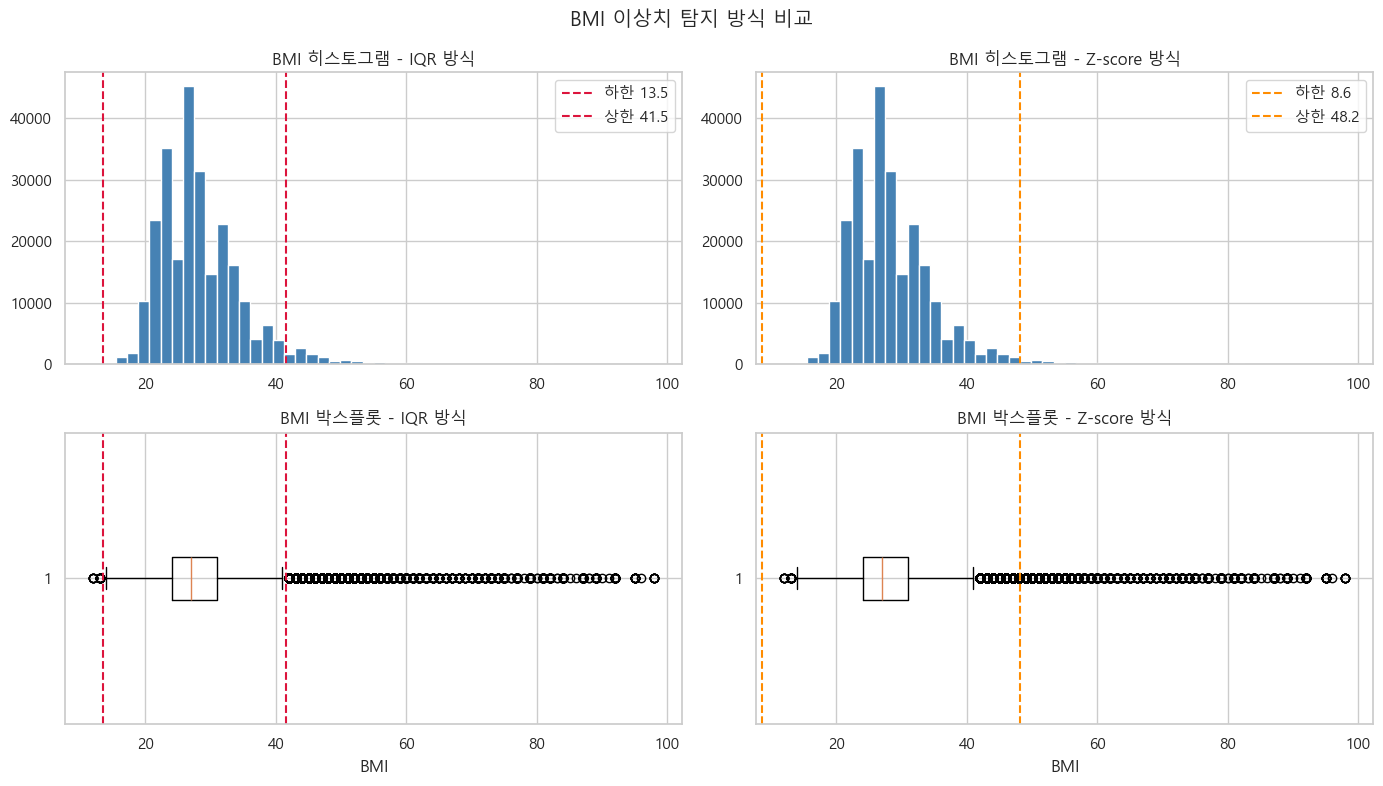

In [2]:
bmi = df['BMI']
q1 = bmi.quantile(0.25)
q3 = bmi.quantile(0.75)
iqr = q3 - q1
iqr_lower = q1 - 1.5 * iqr
iqr_upper = q3 + 1.5 * iqr
iqr_mask = detect_outliers_iqr(bmi)

z_scores = np.abs(stats.zscore(bmi))
z_mask = detect_outliers_zscore(bmi, threshold=3.0)
z_mean = bmi.mean()
z_std = bmi.std(ddof=0)
z_lower = z_mean - 3 * z_std
z_upper = z_mean + 3 * z_std

print(f'IQR 이상치 수: {iqr_mask.sum()} ({iqr_mask.mean():.2%})')
print(f'Z-score 이상치 수: {z_mask.sum()} ({z_mask.mean():.2%})')
print(f'IQR 이상치 범위: {iqr_lower:.2f} ~ {iqr_upper:.2f}')
print(f'Z-score 이상치 범위: {z_lower:.2f} ~ {z_upper:.2f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(bmi, bins=50, color='steelblue', edgecolor='white')
axes[0, 0].axvline(iqr_lower, color='crimson', linestyle='--', label=f'하한 {iqr_lower:.1f}')
axes[0, 0].axvline(iqr_upper, color='crimson', linestyle='--', label=f'상한 {iqr_upper:.1f}')
axes[0, 0].set_title('BMI 히스토그램 - IQR 방식')
axes[0, 0].legend()

axes[0, 1].hist(bmi, bins=50, color='steelblue', edgecolor='white')
axes[0, 1].axvline(z_lower, color='darkorange', linestyle='--', label=f'하한 {z_lower:.1f}')
axes[0, 1].axvline(z_upper, color='darkorange', linestyle='--', label=f'상한 {z_upper:.1f}')
axes[0, 1].set_title('BMI 히스토그램 - Z-score 방식')
axes[0, 1].legend()

axes[1, 0].boxplot(bmi, vert=False)
axes[1, 0].axvline(iqr_lower, color='crimson', linestyle='--')
axes[1, 0].axvline(iqr_upper, color='crimson', linestyle='--')
axes[1, 0].set_title('BMI 박스플롯 - IQR 방식')
axes[1, 0].set_xlabel('BMI')

axes[1, 1].boxplot(bmi, vert=False)
axes[1, 1].axvline(z_lower, color='darkorange', linestyle='--')
axes[1, 1].axvline(z_upper, color='darkorange', linestyle='--')
axes[1, 1].set_title('BMI 박스플롯 - Z-score 방식')
axes[1, 1].set_xlabel('BMI')

fig.suptitle('BMI 이상치 탐지 방식 비교')
fig.tight_layout()
fig.savefig(FIGURE_DIR / '01_outlier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 이상치 비교 요약

- IQR은 BMI 기준 더 많은 값을 이상치로 분류하여 정상 범위를 좁게 잡는다.
- Z-score는 평균·표준편차 기반으로 더 보수적으로 이상치를 탐지한다.
- 최종 선택: Z-score (threshold=3) 클리핑 방식 적용 (제거 아님)

## 섹션 3 — 결측치 대체 비교

주입된 BMI 결측치 개수: 12684 (5.00%)


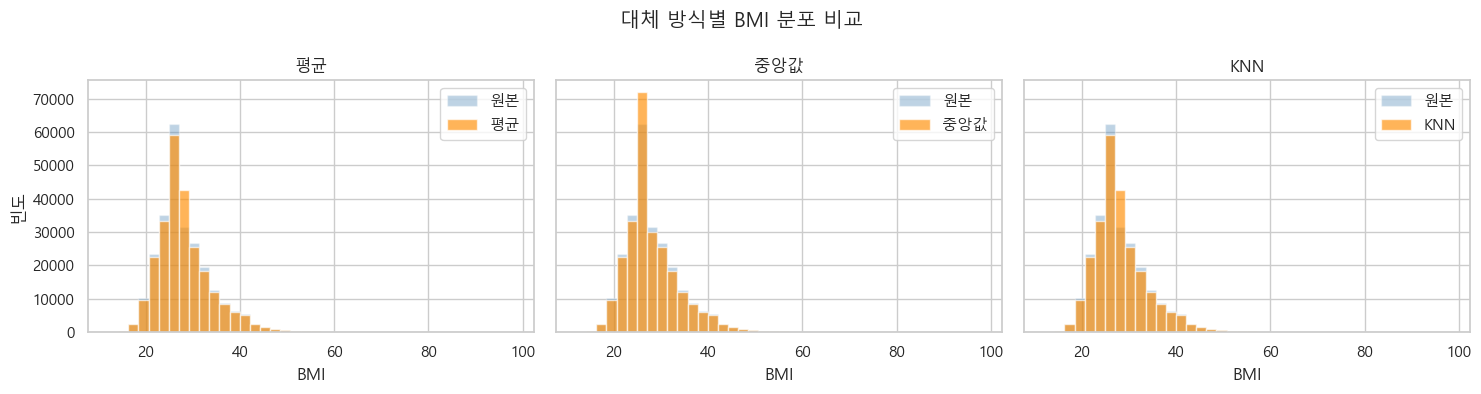

,전략,평균,중앙값,표준편차,최솟값,최댓값
0,평균,28.378,27.0,6.448,12.0,98.0
1,중앙값,28.309,27.0,6.455,12.0,98.0
2,KNN,28.378,27.0,6.448,12.0,98.0


In [3]:
test_df = df.copy()
missing_index = test_df.sample(frac=0.05, random_state=42).index
test_df.loc[missing_index, 'BMI'] = np.nan

strategies = {
    '평균': SimpleImputer(strategy='mean'),
    '중앙값': SimpleImputer(strategy='median'),
    'KNN': KNNImputer(n_neighbors=5),
}

original_bmi = df['BMI']
print(f'주입된 BMI 결측치 개수: {test_df["BMI"].isna().sum()} ({test_df["BMI"].isna().mean():.2%})')

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
imputation_summary = []

for ax, (name, imputer) in zip(axes, strategies.items()):
    filled = imputer.fit_transform(test_df[['BMI']]).ravel()
    ax.hist(original_bmi, bins=40, alpha=0.35, label='원본', color='steelblue')
    ax.hist(filled, bins=40, alpha=0.65, label=name, color='darkorange')
    ax.set_title(name)
    ax.set_xlabel('BMI')
    ax.legend()
    imputation_summary.append({
        '전략': name,
        '평균': filled.mean(),
        '중앙값': np.median(filled),
        '표준편차': filled.std(),
        '최솟값': filled.min(),
        '최댓값': filled.max(),
    })

axes[0].set_ylabel('빈도')
fig.suptitle('대체 방식별 BMI 분포 비교')
fig.tight_layout()
fig.savefig(FIGURE_DIR / '01_imputation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

display(pd.DataFrame(imputation_summary).round(3))

### 결측치 대체 비교 요약

- 실제 결측치가 없어 BMI 5%를 임의로 NaN 처리하여 비교했다.
- 평균·중앙값 대체는 분포 형태를 거의 보존한다.
- KNN 대체는 더 정밀하나 253,680행에서 연산 비용이 크다.
- 최종 선택: 중앙값 대체 (파이프라인 안전망으로 포함)

## 섹션 4 — 클래스 불균형 처리 비교

샘플링 없음: Recall = 0.1578 ± 0.0026


SMOTE: Recall = 0.7619 ± 0.0022


언더샘플링: Recall = 0.7645 ± 0.0038


SMOTE+언더샘플링: Recall = 0.7616 ± 0.0029


,전략,평균 Recall,Recall 표준편차
2,언더샘플링,0.764473,0.003782
1,SMOTE,0.761927,0.002201
3,SMOTE+언더샘플링,0.761608,0.002942
0,샘플링 없음,0.157831,0.002580


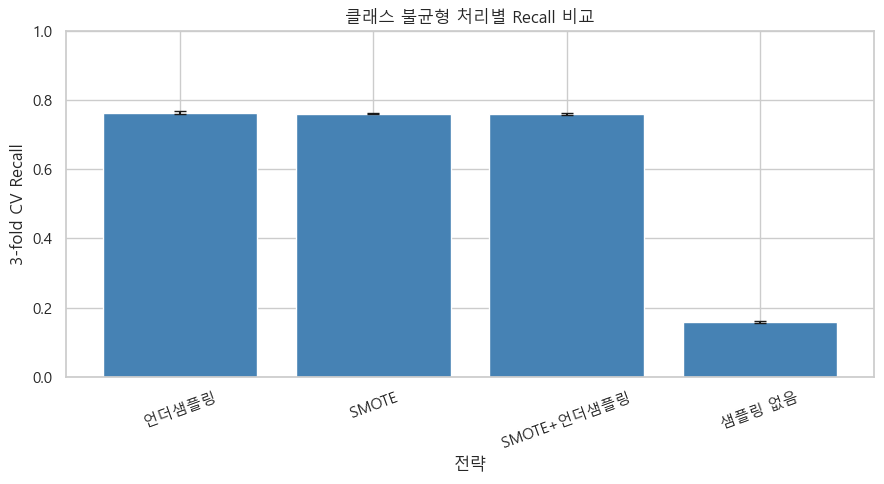

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

strategies = {
    '샘플링 없음': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)),
    ]),
    'SMOTE': ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('lr', LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)),
    ]),
    '언더샘플링': ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('rus', RandomUnderSampler(random_state=42)),
        ('lr', LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)),
    ]),
    'SMOTE+언더샘플링': ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
        ('rus', RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
        ('lr', LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)),
    ]),
}

sampling_results = []
for name, model in strategies.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall', n_jobs=1)
    sampling_results.append({'전략': name, '평균 Recall': scores.mean(), 'Recall 표준편차': scores.std()})
    print(f'{name}: Recall = {scores.mean():.4f} ± {scores.std():.4f}')

sampling_results_df = pd.DataFrame(sampling_results).sort_values('평균 Recall', ascending=False)
display(sampling_results_df)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(sampling_results_df['전략'], sampling_results_df['평균 Recall'], yerr=sampling_results_df['Recall 표준편차'], color='steelblue', capsize=4)
ax.set_title('클래스 불균형 처리별 Recall 비교')
ax.set_xlabel('전략')
ax.set_ylabel('3-fold CV Recall')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(FIGURE_DIR / '01_sampling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 클래스 불균형 처리 비교 요약

- 클래스 비율: 정상 86.07%, 당뇨 13.93%로 유의미한 불균형이 존재한다.
- 불균형 처리 없이 학습 시 다수 클래스 위주 예측으로 Recall이 크게 낮아진다.
- 최종 선택: SMOTE + 언더샘플링 결합 (SMOTE로 소수 클래스 보강 후 균형 조정)

## 섹션 5 — 피처 엔지니어링 점검

### 스케일링 비교

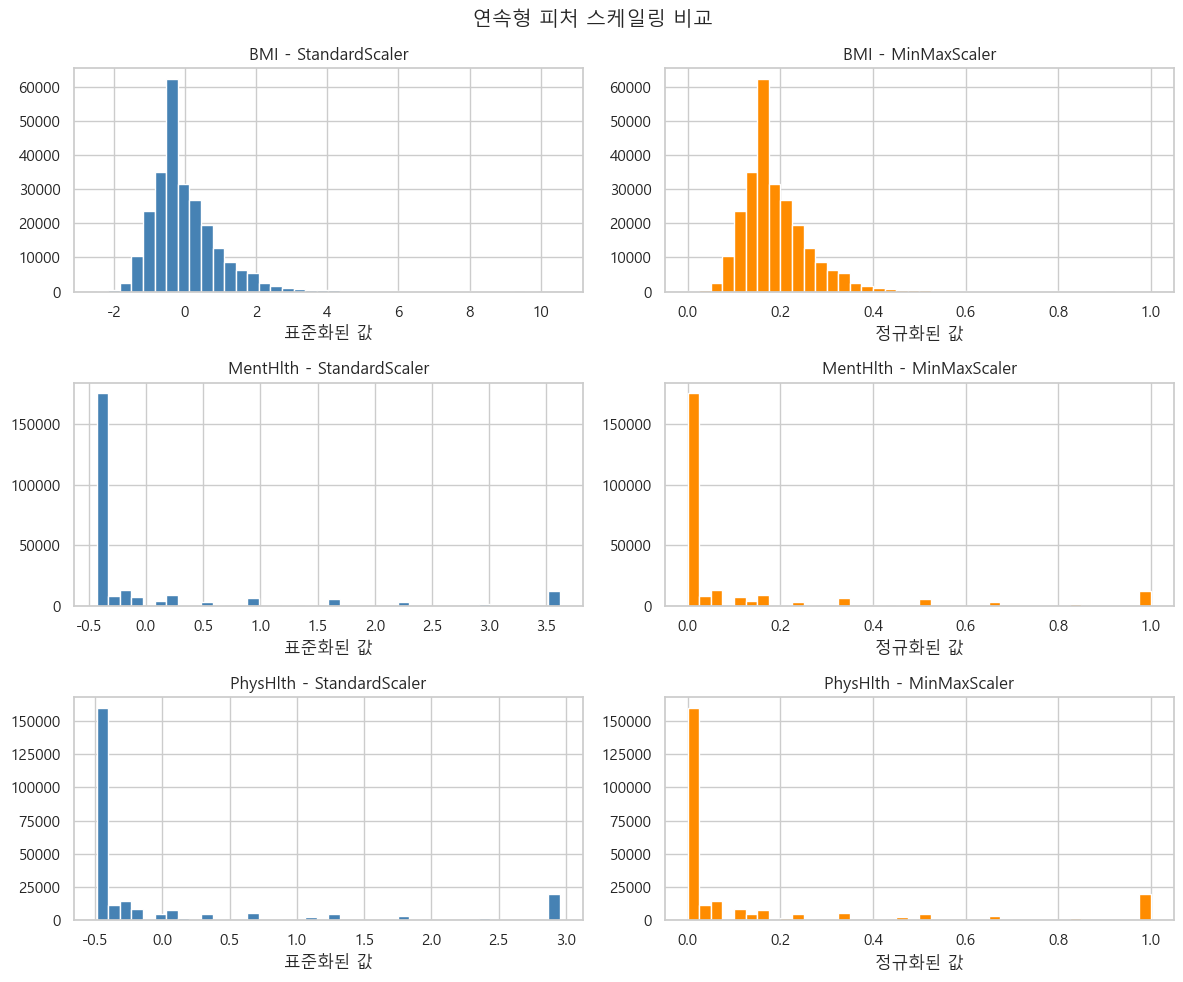

,피처,Standard 평균,Standard 표준편차,MinMax 최솟값,MinMax 최댓값
0,BMI,-0.0,1.0,0.0,1.0
1,MentHlth,0.0,1.0,0.0,1.0
2,PhysHlth,0.0,1.0,0.0,1.0


In [5]:
fig, axes = plt.subplots(len(continuous_features), 2, figsize=(12, 10))
scaling_summary = []

for i, col in enumerate(continuous_features):
    std_vals = StandardScaler().fit_transform(df[[col]]).ravel()
    mmx_vals = MinMaxScaler().fit_transform(df[[col]]).ravel()

    axes[i, 0].hist(std_vals, bins=40, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{col} - StandardScaler')
    axes[i, 0].set_xlabel('표준화된 값')

    axes[i, 1].hist(mmx_vals, bins=40, color='darkorange', edgecolor='white')
    axes[i, 1].set_title(f'{col} - MinMaxScaler')
    axes[i, 1].set_xlabel('정규화된 값')

    scaling_summary.append({
        '피처': col,
        'Standard 평균': std_vals.mean(),
        'Standard 표준편차': std_vals.std(),
        'MinMax 최솟값': mmx_vals.min(),
        'MinMax 최댓값': mmx_vals.max(),
    })

fig.suptitle('연속형 피처 스케일링 비교')
fig.tight_layout()
fig.savefig(FIGURE_DIR / '01_scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

display(pd.DataFrame(scaling_summary).round(3))

### 다중공선성 점검 (VIF)

In [6]:
vif_df = pd.DataFrame({
    '피처': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
}).sort_values('VIF', ascending=False)

high_vif_df = vif_df[vif_df['VIF'] > 10]
print('VIF 전체 결과')
display(vif_df)
print('VIF 10 초과 피처')
display(high_vif_df)

VIF 전체 결과


,피처,VIF
19,Education,29.507416
2,CholCheck,23.187436
11,AnyHealthcare,20.839710
3,BMI,18.149913
20,Income,14.156118
13,GenHlth,10.740162
18,Age,9.886830
9,Veggies,5.826886
7,PhysActivity,4.645314
8,Fruits,3.032775


VIF 10 초과 피처


,피처,VIF
19,Education,29.507416
2,CholCheck,23.187436
11,AnyHealthcare,20.839710
3,BMI,18.149913
20,Income,14.156118
13,GenHlth,10.740162


## 섹션 6 — 최종 파이프라인 구성

In [7]:
final_pipeline = ImbPipeline([
    ('clipper', ZScoreClipper(columns=continuous_features, threshold=3.0)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
    ('undersampler', RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_res, y_train_res = final_pipeline.fit_resample(X_train, y_train)
inference_preprocessor = Pipeline([
    ('clipper', final_pipeline.named_steps['clipper']),
    ('imputer', final_pipeline.named_steps['imputer']),
    ('scaler', final_pipeline.named_steps['scaler']),
])
X_test_processed = inference_preprocessor.transform(X_test)

print(f'전처리 전 훈련 데이터 크기: {X_train.shape}')
print(f'리샘플링 후 X_train_res 크기: {X_train_res.shape}')
print(f'전처리 후 X_test 크기: {X_test_processed.shape}')
print(f'리샘플링 후 y_train_res 크기: {y_train_res.shape}')
print(f'리샘플링 후 클래스 비율:\n{pd.Series(y_train_res).value_counts(normalize=True).round(4)}')
print('Z-score 클리핑 범위 확인')
display(pd.DataFrame({
    '하한': final_pipeline.named_steps['clipper'].lower_bounds_,
    '상한': final_pipeline.named_steps['clipper'].upper_bounds_,
}).round(3))

joblib.dump((X_train_res, X_test_processed, y_train_res, y_test), MODEL_DIR / 'train_test_split.pkl')
joblib.dump(inference_preprocessor, MODEL_DIR / 'preprocessing_pipeline.pkl')
print('저장 완료: outputs/models/train_test_split.pkl')
print('저장 완료: outputs/models/preprocessing_pipeline.pkl')

전처리 전 훈련 데이터 크기: (202944, 21)
리샘플링 후 X_train_res 크기: (174666, 21)
전처리 후 X_test 크기: (50736, 21)
리샘플링 후 y_train_res 크기: (174666,)
리샘플링 후 클래스 비율:
Diabetes_binary
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64
Z-score 클리핑 범위 확인


,하한,상한
BMI,8.583,48.173
MentHlth,-19.063,25.443
PhysHlth,-21.926,30.428


저장 완료: outputs/models/train_test_split.pkl
저장 완료: outputs/models/preprocessing_pipeline.pkl


## 섹션 7 — 전처리 전후 통계 비교

In [8]:
before = X.describe()
after = pd.DataFrame(X_train_res, columns=X.columns).describe()

comparison = pd.concat([before, after], keys=['전처리 전', '전처리 후'], axis=1)
display(comparison)

전처리 전                                               \
              HighBP       HighChol      CholCheck            BMI   
count  253680.000000  253680.000000  253680.000000  253680.000000   
mean        0.429001       0.424121       0.962670      28.382364   
std         0.494934       0.494210       0.189571       6.608694   
min         0.000000       0.000000       0.000000      12.000000   
25%         0.000000       0.000000       1.000000      24.000000   
50%         0.000000       0.000000       1.000000      27.000000   
75%         1.000000       1.000000       1.000000      31.000000   
max         1.000000       1.000000       1.000000      98.000000   

                                                                         \
              Smoker         Stroke HeartDiseaseorAttack   PhysActivity   
count  253680.000000  253680.000000        253680.000000  253680.000000   
mean        0.443169       0.040571             0.094186       0.756544   
std         0.496761       0.197294             0.292087       0.429169   
min         0.000000       0.000000             0.000000       0.000000   
25%         0.000000       0.000000             0.000000       1.000000   
50%         0.000000       0.000000             0.000000       1.000000   
75%         1.000000       0.000000             0.000000       1.000000   
max         1.000000       1.000000             1.000000       1.000000   

                                     ...          전처리 후                 \
              Fruits        Veggies  ...  AnyHealthcare    NoDocbcCost   
count  253680.000000  253680.000000  ...  174666.000000  174666.000000   
mean        0.634256       0.811420  ...       0.017567       0.030840   
std         0.481639       0.391175  ...       0.962154       1.044258   
min         0.000000       0.000000  ...      -4.412533      -0.304052   
25%         0.000000       1.000000  ...       0.226627      -0.304052   
50%         1.000000       1.000000  ...       0.226627      -0.304052   
75%         1.000000       1.000000  ...       0.226627      -0.304052   
max         1.000000       1.000000  ...       0.226627       3.288911   

                                                                   \
             GenHlth       MentHlth       PhysHlth       DiffWalk   
count  174666.000000  174666.000000  174666.000000  174666.000000   
mean        0.305359       0.057901       0.168720       0.229812   
std         1.018288       1.072600       1.139450       1.162180   
min        -1.415079      -0.447152      -0.487165      -0.449615   
25%        -0.479079      -0.447152      -0.487165      -0.449615   
50%         0.456922      -0.447152      -0.487165      -0.449615   
75%         1.203256      -0.145618       0.091392       2.224124   
max         2.328923       3.388753       2.950984       2.224124   

                                                                   
                 Sex            Age      Education         Income  
count  174666.000000  174666.000000  174666.000000  174666.000000  
mean        0.033414       0.194466      -0.122290      -0.160106  
std         0.997452       0.911248       1.016838       1.023289  
min        -0.888229      -2.304802      -4.105839      -2.436889  
25%        -0.888229      -0.338479      -1.064421      -0.989470  
50%        -0.888229       0.316963      -0.050614      -0.024525  
75%         1.125835       0.925135       0.963192       0.940421  
max         1.125835       1.627845       0.963192       0.940421  

[8 rows x 42 columns]